# Semantic Join Analysis with Freyja Benchmark

This notebook explores semantic joins using the Freyja benchmark dataset. You will implement Jaccard similarity and set containment measures to analyze how different tables can be joined based on their column values.

## 1. Setup and Imports


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Set, Tuple, List
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Load Interesting Tables

We'll work with 5 interesting tables from the Freyja benchmark that have rich semantic relationships:


In [25]:
# Define paths
DATALAKE_DIR = "./freyja-semantic-join/datalake/"
GROUND_TRUTH_FILE = "./freyja-semantic-join/freyja_ground_truth.csv"

# Load our selected interesting tables
tables = {}

# 1. World Country Data - comprehensive country information (LARGE, ~239 countries)
tables['world_country'] = pd.read_csv(f"{DATALAKE_DIR}world_country.csv")
print(f"World Country: {tables['world_country'].shape[0]} rows, {tables['world_country'].shape[1]} columns")
print(f"Columns: {list(tables['world_country'].columns)}")

# 2. Countries and Continents - detailed country metadata (MEDIUM, ~251 countries)
tables['countries_continents'] = pd.read_csv(f"{DATALAKE_DIR}countries_and_continents.csv")
print(f"\nCountries & Continents: {tables['countries_continents'].shape[0]} rows, {tables['countries_continents'].shape[1]} columns")
print(f"Columns: {list(tables['countries_continents'].columns)}")

# 3. USA Cars Dataset - cars from USA only (SMALL, only "usa" values - demonstrates Jaccard bias!)
tables['usa_cars'] = pd.read_csv(f"{DATALAKE_DIR}USA_cars_datasets.csv")
print(f"\nUSA Cars: {tables['usa_cars'].shape[0]} rows, {tables['usa_cars'].shape[1]} columns")
print(f"Columns: {list(tables['usa_cars'].columns)}")

# 4. Language Dataset - languages by country codes (MEDIUM, ~2670 languages)
tables['language'] = pd.read_csv(f"{DATALAKE_DIR}language.csv")
print(f"\nLanguage: {tables['language'].shape[0]} rows, {tables['language'].shape[1]} columns")
print(f"Columns: {list(tables['language'].columns)}")

# 5. World Cities - cities with countries (LARGE, ~23000 cities - many countries)
tables['world_cities'] = pd.read_csv(f"{DATALAKE_DIR}world-cities.csv")
print(f"\nWorld Cities: {tables['world_cities'].shape[0]} rows, {tables['world_cities'].shape[1]} columns")
print(f"Columns: {list(tables['world_cities'].columns)}")

# 6. Slogan List - company slogans (NO COUNTRY COLUMN - false positive example!)
tables['sloganlist'] = pd.read_csv(f"{DATALAKE_DIR}sloganlist.csv")
print(f"\nSlogan List: {tables['sloganlist'].shape[0]} rows, {tables['sloganlist'].shape[1]} columns")
print(f"Columns: {list(tables['sloganlist'].columns)}")

# Load ground truth for evaluation
ground_truth = pd.read_csv(GROUND_TRUTH_FILE)
print(f"\nGround Truth: {ground_truth.shape[0]} semantic join pairs")

print("\n✅ All tables loaded successfully!")


World Country: 239 rows, 15 columns
Columns: ['Code', 'Name', 'Continent', 'Region', 'SurfaceArea', 'IndepYear', 'Population', 'LifeExpectancy', 'GNP', 'GNPOld', 'LocalName', 'GovernmentForm', 'HeadOfState', 'Capital', 'Code2']

Countries & Continents: 251 rows, 27 columns
Columns: ['name', 'official_name_en', 'official_name_fr', 'ISO3166-1-Alpha-2', 'ISO3166-1-Alpha-3', 'M49', 'ITU', 'MARC', 'WMO', 'DS', 'Dial', 'FIFA', 'FIPS', 'GAUL', 'IOC', 'ISO4217-currency_alphabetic_code', 'ISO4217-currency_country_name', 'ISO4217-currency_minor_unit', 'ISO4217-currency_name', 'ISO4217-currency_numeric_code', 'is_independent', 'Capital', 'Continent', 'TLD', 'Languages', 'Geoname_ID', 'EDGAR']

USA Cars: 2499 rows, 13 columns
Columns: ['id', 'price', 'brand', 'model', 'year', 'titlestatus', 'mileage', 'color', 'vin', 'lot', 'state', 'country', 'condition']

Language: 2679 rows, 8 columns
Columns: ['walsCode', 'isoCode', 'glottocode', 'Name', 'genus', 'family', 'macroarea', 'countrycodes']

World C

## 3. Explore the Data

Let's examine the country-related columns in our tables to understand the semantic relationships:


In [26]:
# Examine country columns across tables
country_columns = {
    'world_country': 'Name',
    'countries_continents': 'name',
    'usa_cars': 'country',  # Only contains "usa" - demonstrates Jaccard bias!
    'language': 'countrycodes',  # Country codes like "US", "CA", etc.
    'world_cities': 'country',
    # Note: sloganlist has NO country column - this will create false positives!
}

print("Country-related columns and sample values:")
print("=" * 60)

for table_name, col_name in country_columns.items():
    df = tables[table_name]
    unique_countries = df[col_name].dropna().unique()[:10]  # First 10 unique values
    print(f"\n{table_name}.{col_name}:")
    print(f"  Total unique values: {df[col_name].nunique()}")
    print(f"  Sample values: {list(unique_countries)}")

print("\n" + "=" * 60)
print("IMPORTANT OBSERVATIONS:")
print("=" * 60)
print("1. usa_cars.country has ONLY 'usa' values - perfect for demonstrating Jaccard bias!")
print("2. language.countrycodes uses 2-letter codes (US, CA) vs full names")
print("3. sloganlist has NO country column - will create false positives!")
print("4. Different table sizes will show Jaccard's bias toward smaller sets")


Country-related columns and sample values:

world_country.Name:
  Total unique values: 239
  Sample values: ['Aruba', 'Afghanistan', 'Angola', 'Anguilla', 'Albania', 'Andorra', 'Netherlands Antilles', 'United Arab Emirates', 'Argentina', 'Armenia']

countries_continents.name:
  Total unique values: 249
  Sample values: ['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola', 'Anguilla', 'Antarctica', 'Antigua & Barbuda', 'Argentina']

usa_cars.country:
  Total unique values: 2
  Sample values: [' usa', ' canada']

language.countrycodes:
  Total unique values: 371
  Sample values: ['PG', 'ET', 'TD', 'CI', 'LB', 'BH', 'AR', 'GE', 'US', 'AU']

world_cities.country:
  Total unique values: 244
  Sample values: ['Andorra', 'United Arab Emirates', 'Afghanistan', 'Antigua and Barbuda', 'Anguilla', 'Albania', 'Armenia', 'Angola', 'Argentina', 'American Samoa']

IMPORTANT OBSERVATIONS:
1. usa_cars.country has ONLY 'usa' values - perfect for demonstrating Jaccard bias!
2. lang

## 4. Understanding Jaccard Bias and False Positives

**Key Learning Points:**

### Jaccard Similarity Bias
Jaccard similarity has a **bias toward smaller sets**. Consider:
- **Small set A**: {USA} (1 element)
- **Large set B**: {USA, Canada, Mexico, France, Germany, ...} (100+ elements)
- **Jaccard(A,B)**: 1/100+ ≈ 0.01 (very low!)
- **But**: Set A is 100% contained in B!

### False Positives
Some tables may appear semantically related but aren't:
- **sloganlist**: Company slogans (no country data)
- **language**: Language codes vs country names
- **Different formats**: "USA" vs "US" vs "United States"

### Our Table Selection Strategy
1. **world_country** (239 countries) - Large, comprehensive
2. **countries_continents** (251 countries) - Medium, similar to world_country
3. **usa_cars** (only "usa") - **Perfect for demonstrating Jaccard bias!**
4. **language** (country codes) - **Format mismatch creates false positives**
5. **world_cities** (23K cities) - **Very large, many countries**
6. **sloganlist** (no country) - **False positive example**


## 4. Implement Jaccard Similarity

**Your Task**: Implement the `jaccard_similarity` function that calculates the Jaccard similarity between two columns.

The Jaccard similarity is defined as: $J(A,B) = \frac{|A \cap B|}{|A \cup B|}$

**Requirements**:
- Normalize values by removing special characters and converting to lowercase
- Handle missing values appropriately
- Return a value between 0 and 1


In [ ]:
def jaccard_similarity(series_a: pd.Series, series_b: pd.Series) -> float:
    """
    Calculate Jaccard similarity between two columns.
    
    Args:
        series_a: pandas Series
        series_b: pandas Series
    
    Returns:
        float: Jaccard similarity score between 0 and 1
    """
    # TODO: Implement Jaccard similarity
    import re

    def normalize_value(val):
        if pd.isnull(val):
            return None
        # Convert to string, lowercase, remove special chars, strip
        val_str = str(val).lower()
        val_str = re.sub(r'[^a-z0-9]+', ' ', val_str)
        val_str = val_str.strip()
        if val_str == '':
            return None
        return val_str

    # Drop NA and normalize both series
    norm_a = series_a.dropna().map(normalize_value)
    norm_b = series_b.dropna().map(normalize_value)

    # Remove None values produced by normalization
    set_a = set(filter(lambda x: x is not None, norm_a))
    set_b = set(filter(lambda x: x is not None, norm_b))

    if not set_a and not set_b:
        return 1.0  # both empty => identical
    if not set_a or not set_b:
        return 0.0

    intersection = set_a & set_b
    union = set_a | set_b

    return len(intersection) / len(union)
    # pass  # Replace with your implementation

# Test your implementation
def test_jaccard_similarity():
    """Test the jaccard_similarity function with sample data"""
    # Test case 1: Identical sets
    series1 = pd.Series(['USA', 'Canada', 'Mexico'])
    series2 = pd.Series(['USA', 'Canada', 'Mexico'])
    result1 = jaccard_similarity(series1, series2)
    print(f"Test 1 - Identical sets: {result1} (expected: 1.0)")
    
    # Test case 2: No overlap
    series3 = pd.Series(['USA', 'Canada'])
    series4 = pd.Series(['France', 'Germany'])
    result2 = jaccard_similarity(series3, series4)
    print(f"Test 2 - No overlap: {result2} (expected: 0.0)")
    
    # Test case 3: Partial overlap
    series5 = pd.Series(['USA', 'Canada', 'Mexico'])
    series6 = pd.Series(['USA', 'France', 'Germany'])
    result3 = jaccard_similarity(series5, series6)
    print(f"Test 3 - Partial overlap: {result3} (expected: ~0.2)")

# Uncomment to test your implementation
test_jaccard_similarity()


Test 1 - Identical sets: 1.0 (expected: 1.0)
Test 2 - No overlap: 0.0 (expected: 0.0)
Test 3 - Partial overlap: 0.2 (expected: ~0.2)


## 5. Implement Set Containment

**Your Task**: Implement the `set_containment` function that calculates how many values from query column (A) appear in column B.

- $C(A,B) = \frac{|A \cap B|}{|A|}$


In [16]:
def set_containment(series_a: pd.Series, series_b: pd.Series) -> Tuple[float, float]:
    """
    Calculate set containment between two pandas Series.
    
    Args:
        series_a: First pandas Series
        series_b: Second pandas Series
    
    Returns:
        float: |A ∩ B| / |A| (how much of A is in B )
    """
    # TODO: Implement set containment
    # Compute unique elements of A and B
    set_a = set(series_a.dropna().unique())
    set_b = set(series_b.dropna().unique())
    if len(set_a) == 0:
        return 0.0  # Avoid division by zero; define containment as 0 if A is empty
    intersection = set_a & set_b
    containment = len(intersection) / len(set_a)
    return containment
    pass  # Replace with your implementation

# Test your implementation
def test_set_containment():
    """Test the set_containment function with sample data"""
    # Test case 1: A is subset of B
    series1 = pd.Series(['USA', 'Canada'])
    series2 = pd.Series(['USA', 'Canada', 'Mexico', 'France'])
    containment = set_containment(series1, series2)
    print(f"Test 1 - A subset of B: containment={containment:.2f}")
    print(f"  Expected: containment=1.0")
    
    # Test case 2: No overlap
    series3 = pd.Series(['USA', 'Canada'])
    series4 = pd.Series(['France', 'Germany'])
    containment = set_containment(series3, series4)
    print(f"\nTest 2 - No overlap: containment={containment:.2f}")
    print(f"  Expected: containment=0.0")

# Uncomment to test your implementation
test_set_containment()


Test 1 - A subset of B: containment=1.00
  Expected: containment=1.0

Test 2 - No overlap: containment=0.00
  Expected: containment=0.0


## 6. Analyze Semantic Relationships

Now let's use your implementations to analyze the semantic relationships between our tables:


In [18]:
def analyze_table_pairs(tables: dict, country_columns: dict) -> pd.DataFrame:
    """
    Analyze semantic relationships between all pairs of tables.
    
    Args:
        tables: Dictionary of table names to DataFrames
        country_columns: Dictionary mapping table names to their country column names
    
    Returns:
        DataFrame with analysis results
    """
    results = []
    
    table_names = list(tables.keys())
    
    for i, table_a in enumerate(table_names):
        for j, table_b in enumerate(table_names):
            if i < j:  # Only compare each pair once
                col_a = country_columns[table_a]
                col_b = country_columns[table_b]
                
                series_a = tables[table_a][col_a]
                series_b = tables[table_b][col_b]
                
                # Calculate similarities
                jaccard = jaccard_similarity(series_a, series_b)
                containment_score = set_containment(series_a, series_b)
                
                results.append({
                    'table_a': table_a,
                    'column_a': col_a,
                    'table_b': table_b,
                    'column_b': col_b,
                    'jaccard_similarity': jaccard,
                    'set_containment': containment_score,
                    'unique_values_a': series_a.nunique(),
                    'unique_values_b': series_b.nunique()
                })
    
    return pd.DataFrame(results)

# Run the analysis
print("Analyzing semantic relationships between tables...")
print("Note: Make sure you've implemented jaccard_similarity and set_containment functions first!")

# Uncomment when your functions are ready:
results_df = analyze_table_pairs(tables, country_columns)
print("\nAnalysis Results:")
print(results_df.round(3))


Analyzing semantic relationships between tables...
Note: Make sure you've implemented jaccard_similarity and set_containment functions first!

Analysis Results:
                table_a column_a               table_b      column_b  \
0         world_country     Name                movies       country   
1         world_country     Name  countries_continents          name   
2         world_country     Name        netflix_titles       country   
3         world_country     Name          fifa_ranking  country_full   
4                movies  country  countries_continents          name   
5                movies  country        netflix_titles       country   
6                movies  country          fifa_ranking  country_full   
7  countries_continents     name        netflix_titles       country   
8  countries_continents     name          fifa_ranking  country_full   
9        netflix_titles  country          fifa_ranking  country_full   

   jaccard_similarity  set_containment  unique

## 7. Visualize Results

Create visualizations to understand the semantic relationships:


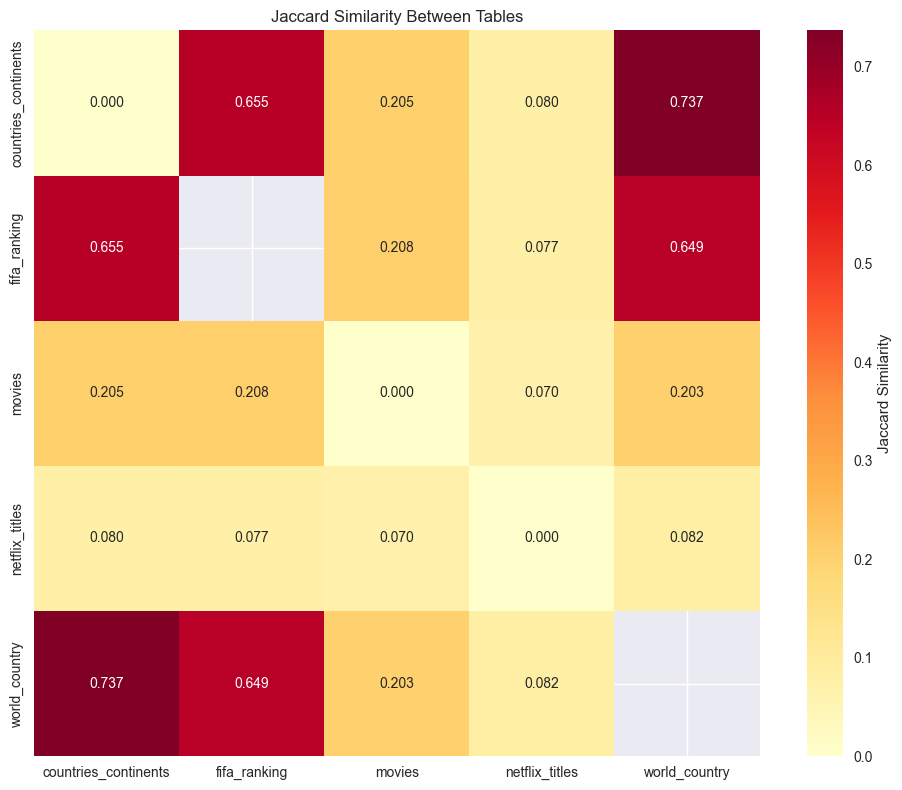

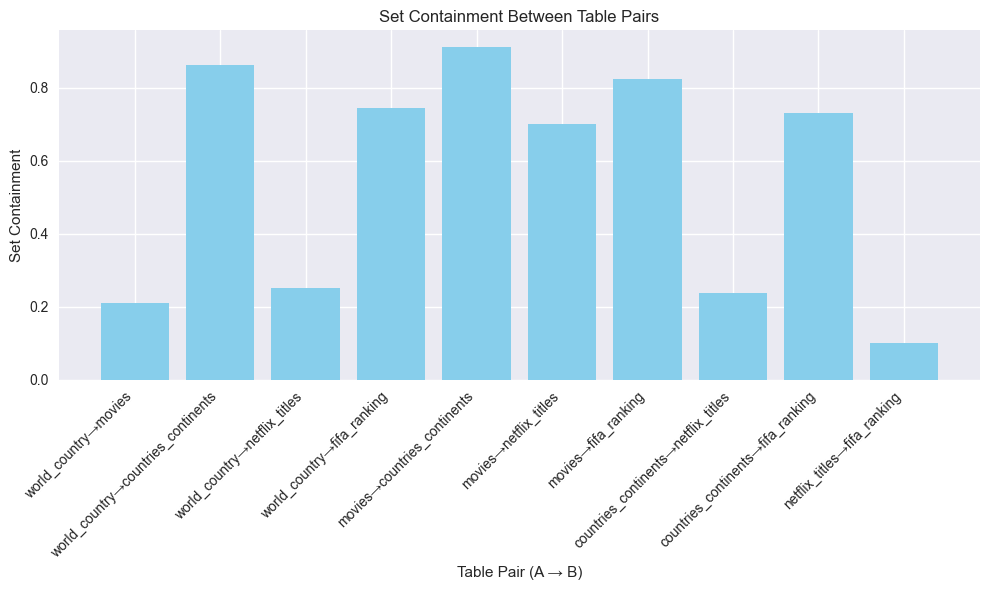

In [20]:
def create_similarity_heatmap(results_df: pd.DataFrame):
    """Create a heatmap of Jaccard similarities between tables"""
    # Create a pivot table for the heatmap
    pivot_data = results_df.pivot_table(
        index='table_a', 
        columns='table_b', 
        values='jaccard_similarity',
        fill_value=0
    )
    
    # Make the matrix symmetric
    pivot_data = pivot_data.add(pivot_data.T, fill_value=0)
    np.fill_diagonal(pivot_data.values, 1.0)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(pivot_data, annot=True, cmap='YlOrRd', fmt='.3f', 
                square=True, cbar_kws={'label': 'Jaccard Similarity'})
    plt.title('Jaccard Similarity Between Tables')
    plt.tight_layout()
    plt.show()

def create_containment_barplot(results_df: pd.DataFrame):
    """Create a bar plot of set containment scores between table pairs"""
    plt.figure(figsize=(10, 6))
    # Create a label for each pair
    pair_labels = results_df.apply(lambda row: f"{row['table_a']}→{row['table_b']}", axis=1)
    plt.bar(pair_labels, results_df['set_containment'], color='skyblue')
    plt.xlabel('Table Pair (A → B)')
    plt.ylabel('Set Containment')
    plt.title('Set Containment Between Table Pairs')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Uncomment when your analysis is ready:
create_similarity_heatmap(results_df)
create_containment_barplot(results_df)


## 8. Evaluate Against Ground Truth

Let's see how our semantic similarity measures align with the ground truth:


In [22]:
def evaluate_against_ground_truth(tables: dict, ground_truth: pd.DataFrame) -> pd.DataFrame:
    """
    Evaluate our similarity measures against the ground truth.

    Args:
        tables: Dictionary of loaded tables
        ground_truth: Ground truth DataFrame with semantic join pairs

    Returns:
        DataFrame with evaluation results
    """
    evaluation_results = []

    # Filter ground truth to only include our tables
    our_tables = set(tables.keys())
    relevant_gt = ground_truth[
        (ground_truth['target_ds'].str.replace('.csv', '').isin(our_tables)) |
        (ground_truth['candidate_ds'].str.replace('.csv', '').isin(our_tables))
    ]

    print(f"Found {len(relevant_gt)} ground truth pairs involving our tables")

    for _, row in relevant_gt.iterrows():
        target_table = row['target_ds'].replace('.csv', '')
        candidate_table = row['candidate_ds'].replace('.csv', '')

        # Skip if either table is not in our loaded tables
        if target_table not in our_tables or candidate_table not in our_tables:
            continue

        try:
            target_col = row['target_attr']
            candidate_col = row['candidate_attr']

            # Get the data
            target_series = tables[target_table][target_col]
            candidate_series = tables[candidate_table][candidate_col]

            # Calculate similarities
            jaccard = jaccard_similarity(target_series, candidate_series)
            set_cont = set_containment(target_series, candidate_series)

            evaluation_results.append({
                'target_table': target_table,
                'target_column': target_col,
                'candidate_table': candidate_table,
                'candidate_column': candidate_col,
                'jaccard_similarity': jaccard,
                'set_containment': set_cont,
                'is_ground_truth': True
            })

        except Exception as e:
            print(f"Error processing {target_table}.{target_col} - {candidate_table}.{candidate_col}: {e}")
            continue

    return pd.DataFrame(evaluation_results)

# Run evaluation
print("Evaluating against ground truth...")
print("Note: Make sure you've implemented the similarity functions first!")

# Uncomment when your functions are ready:
eval_results = evaluate_against_ground_truth(tables, ground_truth)
print(f"\nEvaluated {len(eval_results)} ground truth pairs")
print("\nTop 10 highest Jaccard similarities:")
print(eval_results.nlargest(10, 'jaccard_similarity')[['target_table', 'candidate_table', 'jaccard_similarity']])


Evaluating against ground truth...
Note: Make sure you've implemented the similarity functions first!
Found 274 ground truth pairs involving our tables

Evaluated 23 ground truth pairs

Top 10 highest Jaccard similarities:
      target_table candidate_table  jaccard_similarity
4     fifa_ranking    fifa_ranking            1.000000
9           movies          movies            1.000000
14  netflix_titles  netflix_titles            1.000000
18   world_country   world_country            1.000000
22   world_country   world_country            1.000000
0     fifa_ranking   world_country            0.648551
17   world_country    fifa_ranking            0.648551
1     fifa_ranking          movies            0.207965
7           movies    fifa_ranking            0.207965
5           movies   world_country            0.203252


## 9. Analysis Questions

**Answer these questions based on your analysis:**

1. **Which table pairs have the highest Jaccard similarity?** What does this tell you about the data?

2. **What's the difference between Jaccard similarity and set containment?** When would you use each measure?

3. **Are there any surprising relationships?** Tables that you wouldn't expect to be semantically similar but are?

4. **How do your results compare to the ground truth?** Are there any ground truth pairs with low similarity scores?

5. **What challenges did you encounter?** How did you handle data quality issues like missing values or inconsistent formatting?


In [9]:
# Your analysis and answers go here
print("Analysis Questions:")
print("1. Which table pairs have the highest Jaccard similarity?")
print("2. What's the difference between Jaccard similarity and set containment?")
print("3. Are there any surprising relationships?")
print("4. How do your results compare to the ground truth?")
print("5. What challenges did you encounter?")

# Add your analysis code and answers below:
# ...


Analysis Questions:
1. Which table pairs have the highest Jaccard similarity?
2. What's the difference between Jaccard similarity and set containment?
3. Are there any surprising relationships?
4. How do your results compare to the ground truth?
5. What challenges did you encounter?


## 10. Advanced Analysis (Optional)

**Challenge yourself with these advanced tasks:**

1. **Implement weighted Jaccard similarity** that considers the frequency of values
2. **Create a semantic join recommendation system** that suggests the best join columns
3. **Analyze the impact of data preprocessing** on similarity scores
4. **Compare different normalization strategies** (e.g., stemming, lemmatization)
5. **Implement fuzzy matching** for handling typos and variations


In [10]:
# Advanced analysis code goes here
print("Advanced Analysis Tasks:")
print("1. Implement weighted Jaccard similarity")
print("2. Create a semantic join recommendation system")
print("3. Analyze the impact of data preprocessing")
print("4. Compare different normalization strategies")
print("5. Implement fuzzy matching")

# Add your advanced analysis code below:
# ...


Advanced Analysis Tasks:
1. Implement weighted Jaccard similarity
2. Create a semantic join recommendation system
3. Analyze the impact of data preprocessing
4. Compare different normalization strategies
5. Implement fuzzy matching


## Summary

In this notebook, you've:

1. ✅ Loaded and explored the Freyja benchmark dataset
2. ✅ Implemented Jaccard similarity for measuring value overlap
3. ✅ Implemented set containment measures
4. ✅ Analyzed semantic relationships between tables
5. ✅ Evaluated results against ground truth
6. ✅ Visualized similarity patterns

**Key Takeaways:**
- Semantic joins are crucial for data integration
- Similarity measures help identify joinable columns
- Data quality and preprocessing significantly impact results
- Ground truth validation is essential for evaluation

**Next Steps:**
- Explore more sophisticated similarity measures
- Implement semantic join algorithms
- Work with larger, more complex datasets
- Consider domain-specific similarity functions
